In [1]:
# Dependencies and imports
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from util.plotters import plot_config, create_correlation_matx, plot_correlation_matx, plot_stratified_ecdf

plot_config()

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

Using default theme


/var/folders/xn/6vg5ddx11lbdhtrbqtyh_x600000gn/T/ipykernel_52588/2737042787.py:59: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['home_damage'] = df['home_damage'].replace({


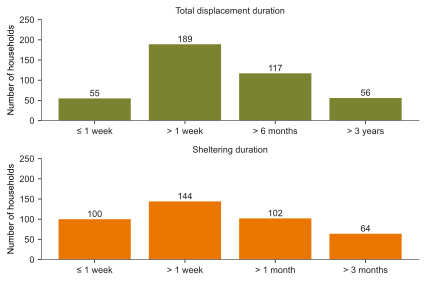

In [2]:
# Organize outcome, treatment, and covariate variables
DAYS_IN_MONTH = 30.437

# Read parsed and anonymized data
data_path = os.path.join("data", 'sample.pkl')
df = pd.read_pickle(data_path)
df.head(5)

# Total displacement durations
otype = "total"
OUTCOME_BINS = {
    '≤ 1 week': 7,
    '> 1 week': 7,
    '> 6 months': DAYS_IN_MONTH * 6,
    '> 3 years': DAYS_IN_MONTH * 36,
}
OUTCOME_LEVELS_T = [otype + '-' + k for k in list(OUTCOME_BINS.keys())]
for outcome in OUTCOME_BINS:
    outcome_label = otype + '-' + outcome
    df[outcome_label] = 0
    threshold = OUTCOME_BINS[outcome]
    is_first_bin = outcome_label == OUTCOME_LEVELS_T[0]
    mask = df[f'duration_{otype}'] * DAYS_IN_MONTH <= threshold if is_first_bin else df[f'duration_{otype}'] * DAYS_IN_MONTH > threshold
    df.loc[mask, outcome_label] = 1

# Emergency displacement durations
otype = "emergency"
OUTCOME_BINS = {
    '≤ 1 week': 7,
    '> 1 week': 7,
    '> 1 month': DAYS_IN_MONTH,
    '> 3 months': DAYS_IN_MONTH * 3,
}
OUTCOME_LEVELS_E = [otype + '-' + k for k in list(OUTCOME_BINS.keys())]
for outcome in OUTCOME_BINS:
    outcome_label = otype + '-' + outcome
    df[outcome_label] = 0
    threshold = OUTCOME_BINS[outcome]
    is_first_bin = outcome_label == OUTCOME_LEVELS_E[0]
    mask = df[f'duration_{otype}'] * DAYS_IN_MONTH <= threshold if is_first_bin else df[f'duration_{otype}'] * DAYS_IN_MONTH > threshold
    df.loc[mask, outcome_label] = 1



COVARIATES = [
    'home_damage', 'comm_damage',
    'bin_land_tenure', 'bin_dwell_tenure',
    # 'structure-concrete_heavy', 'structure-wood_light', 'structure-wood_heavy', 'housing_quality',
    'any_fatality', 'any_injury',
    'hazard_type-earthquake_only', 'hazard_type-tsunami', 'hazard_type-liquefaction',#
    'bin_income', 'edu_household', 
    'bin_household_size', 'elderly', 'children',
    'occupation-agricultural', 'occupation-business', 'occupation-employment', 
    'place_identified', 'place_dependent', 'hometown',
    'aspiration_stay',
]

# Merge home damage categories
df['home_damage'] = df['home_damage'].replace({
    '(45-65%) Heavy damage': '(>45%) Destroyed',
    '(>65%) Completely lost': '(>45%) Destroyed'
})
df['home_damage'] = df['home_damage'].cat.set_categories([
    '(<30%) Minor damage',
    '(30-45%) Moderate damage',
    '(>45%) Destroyed'
], ordered=True)

TREATMENTS = ['home_damage', 'comm_damage', 'any_fatality', 'any_injury',
    'hazard_type-earthquake_only', 'hazard_type-tsunami', 'hazard_type-liquefaction'] # NOTE: These are all related to disaster impact and so need to consider role of time in identification

# Add new treatments (hot-encoded)
base_vars = ['home_damage', 'comm_damage', 'tenure_duration', 'bin_income', 'bin_household_size', 'edu_household', "bin_land_tenure", "bin_dwell_tenure"]
for base_var in base_vars:
    var_opt = list(df[base_var].cat.categories)
    treatments = [base_var + '-' + opt for opt in var_opt]
    for i in range(len(var_opt)):
        idx = df[base_var] == var_opt[i]
        df[treatments[i]] = 0
        df.loc[idx, treatments[i]] = 1
        TREATMENTS.append(treatments[i])

all_cols = list(set(OUTCOME_LEVELS_E + OUTCOME_LEVELS_T + TREATMENTS + COVARIATES))
data = df.copy()
for col in data.columns:
    if data[col].dtype == 'category':
        if (len(data[col].cat.categories) == 2) and (data[col].cat.categories == ['Yes', 'No']).all():
            data[col] = data[col].apply(lambda x: 1 if x == 'Yes' else 0).astype(float)
        else:
            data[col] = data[col].cat.codes
    elif data[col].dtype == 'bool':
        data[col] = data[col].astype(int)

# Collect frequencies of total and emergency duration bins
freq_total = [df[col].sum() for col in OUTCOME_LEVELS_T]
freq_emergency = [df[col].sum() for col in OUTCOME_LEVELS_E]

# Define labels
labels_total = [k.replace('total-', '') for k in OUTCOME_LEVELS_T]
labels_emergency = [k.replace('emergency-', '') for k in OUTCOME_LEVELS_E]

# Define colors
total_colors = ["#d8d6cc", "#c1c78a", "#7b8230", "#3f4625"]
shelter_colors = ["#e7d3ba", "#f5ab5e", "#ea7600", "#733c1c"]

# Plotting
fig, axs = plt.subplots(2, 1, figsize=(6, 4), sharex=False, sharey=True)

# Total duration subplot (green)
axs[0].bar(labels_total, freq_total, color=total_colors[-2])
axs[0].set_title('Total displacement duration')
axs[0].set_ylabel('Number of households')
for i, count in enumerate(freq_total):
    axs[0].text(i, count + 1, f'{int(count)}', ha='center', va='bottom')

# Emergency duration subplot (orange)
axs[1].bar(labels_emergency, freq_emergency, color=shelter_colors[-2])
axs[1].set_title('Sheltering duration')
axs[1].set_ylabel('Number of households')
axs[1].set_xlabel(None)
for i, count in enumerate(freq_emergency):
    axs[1].text(i, count + 1, f'{int(count)}', ha='center', va='bottom')
axs[1].set_ylim((0, 250))

# For outputs
img_folder = "img"
output_total = {}
output_shelter = {}

# Improve layout
plt.tight_layout()
plt.show()

In [3]:
# Organize relevant variables and their friendly names
OUTCOMES = {
    'duration_total': 'Total duration',
    'duration_emergency': 'Sheltering duration'
}
STRATA = {
    'Physical damage': {
        'home_damage': 'Home damage',
        'comm_damage': 'Community damage',
        'hazard_type-earthquake_only': 'Ground shaking only',
        'any_fatality': 'Fatality in household',
        'any_injury': 'Injury in household',
    },
    'Socioeconomic characteristics': {
        'bin_income': 'Household income',
        'edu_household': 'Educational attainment',
        'bin_land_tenure': 'Land tenure',
        'bin_dwell_tenure': 'Dwelling tenure',
        'bin_household_size': 'Household size',
        'occupation-agricultural': 'Agricultural livelihood',
        'occupation-business': 'Business livelihood',
    },
    'Psychological factors': {
        'place_identified': 'Place identified',
        'place_dependent': 'Place dependent',
        'hometown': 'Hometown status',
        'aspiration_stay': 'Stay aspiration',
    },
}

all_covariates = [[var for var in STRATA[strat]] for strat in STRATA.keys()]
COVARIATES = np.concatenate(all_covariates).tolist()
VARS = COVARIATES + list(OUTCOMES.keys())

These 4 columns exceed the tolerance of 65%:
    comm_damage
    hazard_type-earthquake_only
    any_injury
    duration_total

Displaying the top 10 factors correlated with duration_total:
home_damage                65.1%
comm_damage                64.4%
any_injury                 15.9%
any_fatality               13.4%
occupation-agricultural     9.5%
bin_income                  7.7%
edu_household               5.8%
bin_land_tenure             3.6%
bin_dwell_tenure            3.2%
hometown                    3.0%
Name: duration_total, dtype: object

Displaying the top 10 factors correlated with duration_emergency:
comm_damage                33.7%
home_damage                31.2%
place_identified           15.0%
hometown                   12.3%
occupation-agricultural    11.5%
any_injury                  9.1%
any_fatality                7.7%
bin_household_size          7.7%
place_dependent             6.6%
aspiration_stay             4.9%
Name: duration_emergency, dtype: object



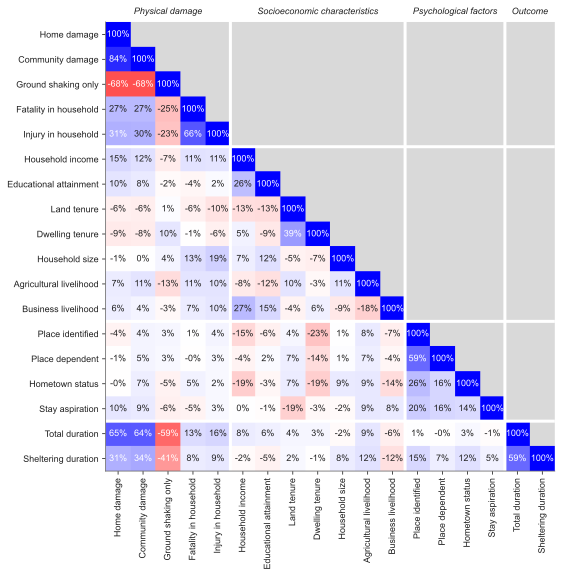

In [4]:
# Determine correlations
corr_tol = 0.65
corr_matx, upper, lower, to_drop = create_correlation_matx(data[VARS], corr_tol=corr_tol, absolute=False, method="spearman")

# Create plot 
scale = 0.45
fig, ax = plt.subplots(figsize=(scale * len(VARS), scale * len(VARS)))
plot_correlation_matx(lower, ax, cmap='bwr_r', groups={**STRATA, 'Outcome': OUTCOMES})
fig.tight_layout()
fig.savefig(os.path.join(img_folder, 'Correlations.png'), dpi=200, facecolor='w', bbox_inches='tight')


# Get top correlated factors with outcomes
n_top = 10
for outcome in OUTCOMES:
    print(f"Displaying the top {n_top} factors correlated with {outcome}:")
    print(corr_matx[outcome].drop(index=OUTCOMES).sort_values(ascending=False).head(n_top).map('{:.1%}'.format))
    print()

# Preview
plt.show()

# Empirical CDF

Stratified empirical CDFs for total displacement durations and sheltering durations. This follows the same approach as in: Paul, Nicole, Eyitayo Opabola, Sukiman Nurdin, Dicky Pelupessy, Aulia Damayanti, Reval Rahmat Nurdin, Shafitri Rayhana, Adam, Sifa Salsabila Sahempa, and Carmine Galasso. “Disaster displacement in context: Household trajectories after the 2018 Central Sulawesi multi-hazard event.” In press.

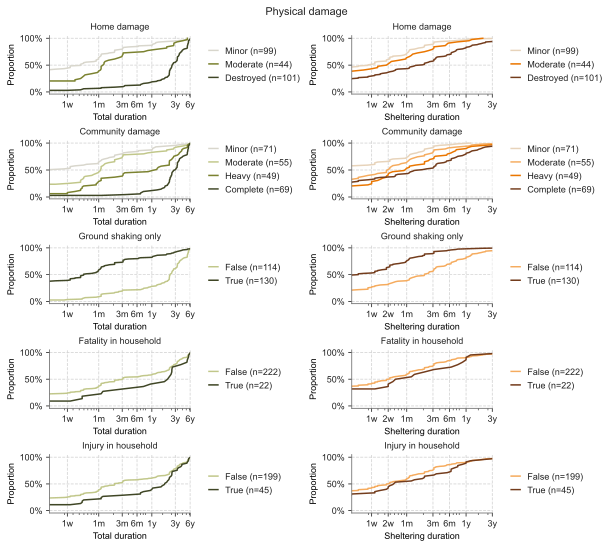

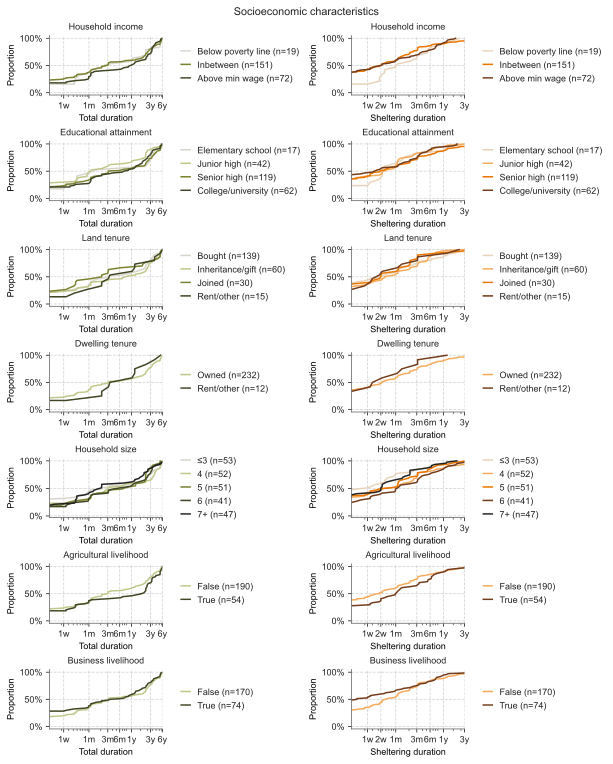

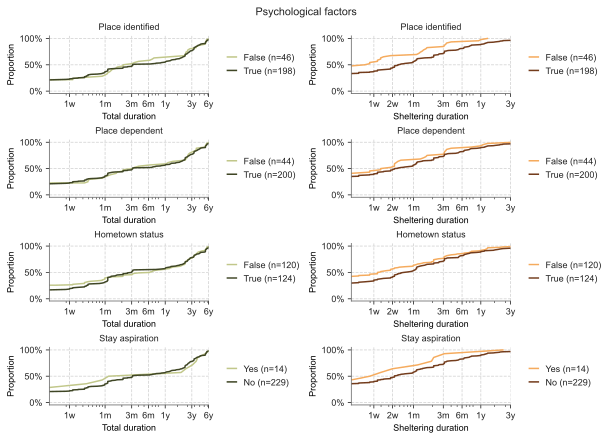

In [5]:
# Stratified ECDF
pf = data.copy()
for category, variables in STRATA.items():
    plot_stratified_ecdf(df, pf, category, OUTCOMES, variables)